In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings

In [ ]:
#Load the dataset
df = pd.read_csv("/content/zomato.csv")
df

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet
...,...,...,...,...,...,...,...,...,...,...,...,...,...
56247,"Four Points by Sheraton Bengaluru, 43/3, White...",Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6 /5,27,080 40301477,Whitefield,Bar,NaN,Continental,"1,500",Pubs and bars
56248,"Number 10, Garudachar Palya, Mahadevapura, Whi...",Vinod Bar And Restaurant,No,No,NaN,0,+91 8197675843,Whitefield,Bar,NaN,Finger Food,600,Pubs and bars
56249,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Plunge - Sheraton Grand Bengaluru Whitefield H...,No,No,NaN,0,NaN,Whitefield,Bar,NaN,Finger Food,"2,000",Pubs and bars
56250,Sheraton Grand Bengaluru Whitefield Hotel & Co...,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3 /5,236,080 49652769,"ITPL Main Road, Whitefield",Bar,"Cocktails, Pizza, Buttermilk",Finger Food,"2,500",Pubs and bars


In [ ]:
df.shape

(56252, 13)

In [ ]:
df.describe()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [ ]:
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [ ]:
df.columns.tolist()

['address',
 'name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'phone',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'approx_cost(for two people)',
 'listed_in(type)']

In [ ]:
df.dtypes

,0
address,object
name,object
online_order,object
book_table,object
rate,object
votes,object
phone,object
location,object
rest_type,object
dish_liked,object


In [ ]:
#Check missing values
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing

,Missing Values,Missing Percentage
dish_liked,28225,50.175994
rate,7838,13.933727
listed_in(type),4610,8.195264
phone,1296,2.303918
approx_cost(for two people),521,0.926189
rest_type,338,0.600868
cuisines,203,0.360876
location,126,0.223992
votes,78,0.138662
book_table,58,0.103107


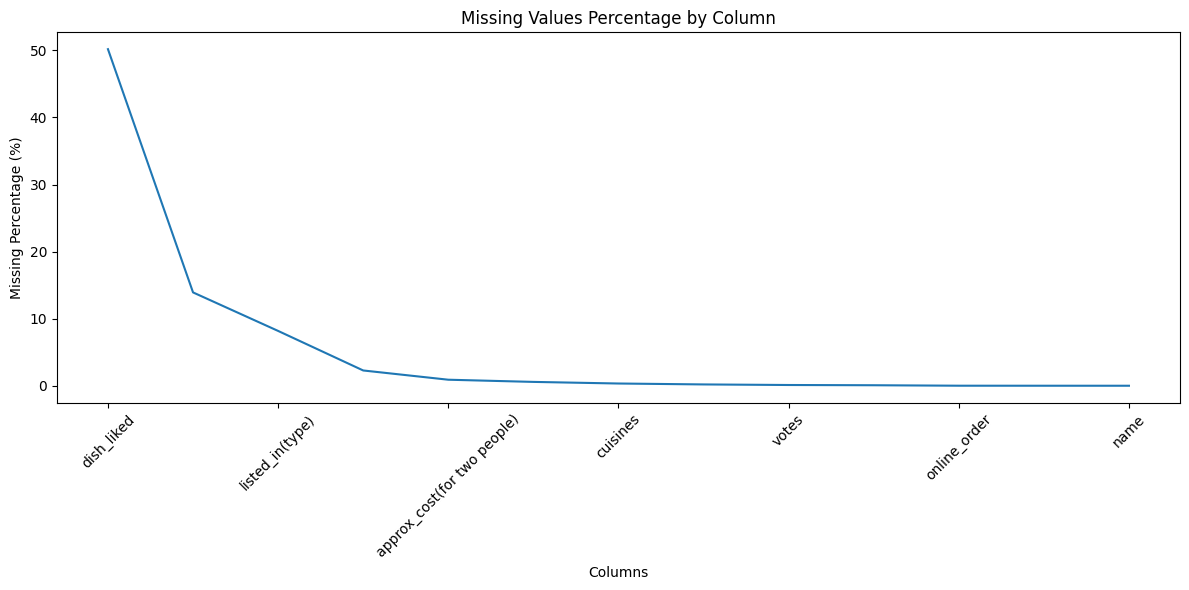

In [ ]:
#Visualization
plt.figure(figsize=(12, 6))

missing["Missing Percentage"].plot(kind="line")

plt.title("Missing Values Percentage by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 15703


In [ ]:
#Remove duplicate Records
df = df.drop_duplicates().copy()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (40549, 13)


In [ ]:
#Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print(df.columns.tolist())

['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_costfor_two_people', 'listed_intype']


In [ ]:
#Clean Rating
df["rate"] = (
    df["rate"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

print(df["rate"].describe())


count    32510.000000
mean         5.369780
std         74.409591
min          0.000000
25%          3.400000
50%          3.800000
75%          4.000000
max       8335.000000
Name: rate, dtype: float64


In [ ]:
#Check
df["rate"].value_counts(dropna=False).head(20)

,count
rate,
NaN,8039
3.9,3052
4.0,2929
3.8,2799
3.7,2787
3.6,2335
4.1,2306
3.5,1987
3.4,1734


In [ ]:
#Clean votes
df["votes"] = pd.to_numeric(
    df["votes"],
    errors="coerce"
)

df["votes"].describe()

,votes
count,36402.000000
mean,309.295533
std,809.804216
min,0.000000
25%,10.000000
50%,54.000000
75%,239.000000
max,16832.000000


In [ ]:
import pandas as pd

#Clean restaurant cost
cost_col = "approx_costfor_two_people"

df[cost_col] = (
    df[cost_col]
    .astype(str)
    .str.replace(",", "", regex=False)
)

df[cost_col] = pd.to_numeric(
    df[cost_col],
    errors="coerce"
)

df[cost_col].describe()

,approx_costfor_two_people
count,36183.000000
mean,575.606417
std,446.887138
min,40.000000
25%,300.000000
50%,450.000000
75%,700.000000
max,6000.000000


In [ ]:
#Clean categorical fields
categorical_columns = [
    "online_order",
    "book_table",
    "location",
    "rest_type",
    "dish_liked",
    "cuisines",
    "listed_in_type"
]

for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

In [ ]:
#Replace fake missing value
missing_values = ["", "nan", "NaN", "None", "null", "-", "NEW"]

df = df.replace(missing_values, np.nan)


In [ ]:
#Check cleaned dataset
print("Final shape:", df.shape)

display(df.head())

display(df.isnull().sum().sort_values(ascending=False))

Final shape: (40549, 13)


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_costfor_two_people,listed_intype
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775.0,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787.0,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918.0,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88.0,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166.0,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet


,0
dish_liked,18226
rate,8039
approx_costfor_two_people,4366
votes,4147
listed_intype,2907
phone,808
rest_type,251
cuisines,151
location,98
book_table,38


In [ ]:
#Handle missing values
rating_df = df.dropna(subset=["rate"]).copy()

print("Records available for rating analysis:", len(rating_df))


Records available for rating analysis: 32510


In [ ]:
#For categorical analysis
analysis_df = df.copy()

for col in ["location", "rest_type", "cuisines", "listed_in_type"]:
    if col in analysis_df.columns:
        analysis_df[col] = analysis_df[col].fillna("Unknown")

In [ ]:
#rating analysis
print("Average Rating:", round(rating_df["rate"].mean(), 2))
print("Median Rating:", rating_df["rate"].median())
print("Minimum Rating:", rating_df["rate"].min())
print("Maximum Rating:", rating_df["rate"].max())

Average Rating: 5.37
Median Rating: 3.8
Minimum Rating: 0.0
Maximum Rating: 8335.0


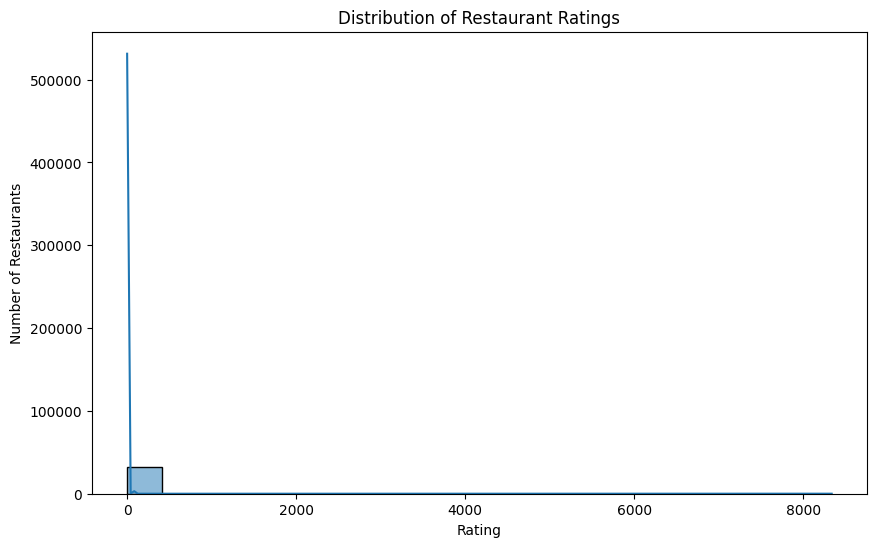

In [ ]:
#Rating distribution
plt.figure(figsize=(10, 6))

sns.histplot(
    rating_df["rate"],
    bins=20,
    kde=True
)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")

plt.show()

In [ ]:
#Rating categories
def rating_category(x):
    if x < 2.5:
        return "Poor"
    elif x < 3.5:
        return "Average"
    elif x < 4.0:
        return "Good"
    else:
        return "Excellent"


rating_df["rating_category"] = rating_df["rate"].apply(rating_category)

rating_df["rating_category"].value_counts()

,count
rating_category,
Good,12960
Excellent,10830
Average,8353
Poor,367


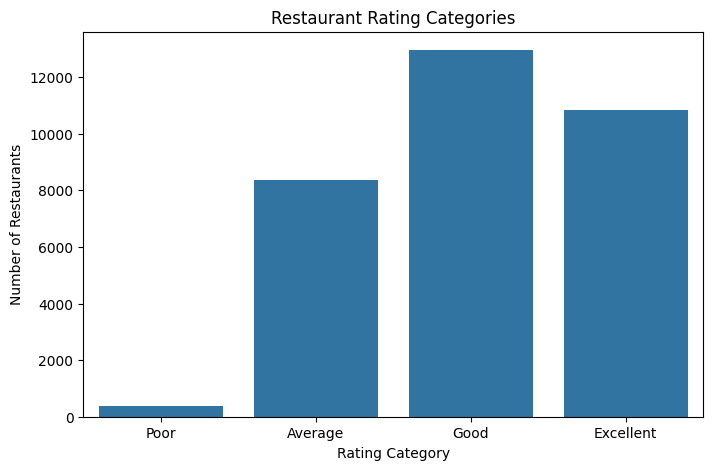

In [ ]:
#Visualization:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=rating_df,
    x="rating_category",
    order=["Poor", "Average", "Good", "Excellent"]
)

plt.title("Restaurant Rating Categories")
plt.xlabel("Rating Category")
plt.ylabel("Number of Restaurants")

plt.show()

In [ ]:
#Online order vs rating
online_rating = (
    rating_df
    .groupby("online_order")["rate"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

online_rating

,count,mean
online_order,,
Smalley's has got a large menu.\n\nAmbience: The ambience is nice,2,8335.0
XO rice,1,3570.0
"and masala peanut for munchies.\n\nThe service was a little slow because of the huge crowd during the festive season but the good food and the ambience compensates well for it."""")",1,3000.0
'RATED\n Fast. Fresh. Flavor. Focus. Operating on these key elements,1,1996.0
'RATED\n This place is part large joint chain of vada pav..\n\nPlace offer consistent material but the cleanliness is last point and the people who are handling food handles all the materials by bare hand in front off you...you will be little skeptically in eating the same..\n\nPlace for self service is big but not managed properly...only stars is for price and food quality...but it has to improve if this has to run for long time...'),1,1100.0
...,...,...
nice aroma and spicy authentic hyderabadi biryani,1,1.0
it's a substandard place to dine in. Menu has number of items but you won't find anything new. Even what is available is sometimes depressing,1,1.0
it is very cheap considering its proximity to Koramangala). Shakes like Oreo shake are also awesome. A lot of residents of various PGs in the area visit this place and hangout with friends in the evening. It is more like a dhaba than a restaurant,2,1.0


In [ ]:
#Table booking vs rating
booking_rating = (
    rating_df
    .groupby("book_table")["rate"]
    .agg(["count", "mean"])
)

booking_rating


,count,mean
book_table,,
"""""Mainland China"""" is the name that comes first to your mind !!\n\nThis restaurant chain is probably the biggest Chinese restaurant chain in the entire country and they are popular in every city they have opened up !! ...... and why won\'t they ? ........ they serve good Chinese food that tastes very good too.\n\nThe Mainland China outlet in Whitefield (Bangalore) is another feather in the cap for this chain ...... You can visit this restaurant (or any Mainland China outlet in that case) if you want to enjoy very good Chinese food !! So ...... Go For It !!')",1,3.0
"""""RATED\n 1Q1 has a great mix of food",1,3.0
"""""RATED\n 3/5 fr the ambience..2/5 fr the quality of food..ordered paneer butter masala for 95 bucks nd was totally disappnted with the curry wch had not more than 7-8 pieces of paneer and was cooked sour n sweet. The speciality here are the wide variety of fruit juices n shakes. From lemon n oranges to kiwi n litchi u 'll find em al.."""")",1,2.5
"""""RATED\n 55 wall street we went recently for a Night out",1,2.0
"""""RATED\n ? MUST TRY: None\n\n?FOOD: 2 ? we had nachos",1,200.0
...,...,...
you would still get to experience most of the food that I would be mentioning as we go along but would miss out on the specials like the Turkey,1,83.0
"you'll be going back for seconds!\n\nThis is my go-to place for anytime I'm in Bangalore!"""")",1,5.0
"you'll be served your order in 10 minutes!\nKudos to these guys!"""")",1,4.0


In [ ]:
#Cuisine vs Rating
cuisine_df = rating_df.dropna(subset=["cuisines"]).copy()

cuisine_df["cuisine"] = cuisine_df["cuisines"].str.split(",")

cuisine_df = cuisine_df.explode("cuisine")

cuisine_df["cuisine"] = cuisine_df["cuisine"].str.strip()
cuisine_analysis = (
    cuisine_df
    .groupby("cuisine")
    .agg(
        restaurant_count=("name", "count"),
        average_rating=("rate", "mean"),
        total_votes=("votes", "sum")
    )
    .reset_index()
)

cuisine_analysis = cuisine_analysis[
    cuisine_analysis["restaurant_count"] >= 30
]

cuisine_analysis = cuisine_analysis.sort_values(
    "average_rating",
    ascending=False
)

cuisine_analysis.head(15)

,cuisine,restaurant_count,average_rating,total_votes
447,('Rated 4.0',154,39.074675,0.0
449,('Rated 5.0',138,37.050725,0.0
445,('Rated 3.0',75,30.160000,0.0
441,('Rated 1.0',33,7.772727,0.0
611,Singaporean,36,4.405556,42865.0
575,Modern Indian,108,4.329630,117287.0
567,Malaysian,76,4.296053,96030.0
548,Japanese,233,4.257940,257413.0
570,Mediterranean,393,4.231043,694836.0
561,Korean,105,4.179048,84708.0


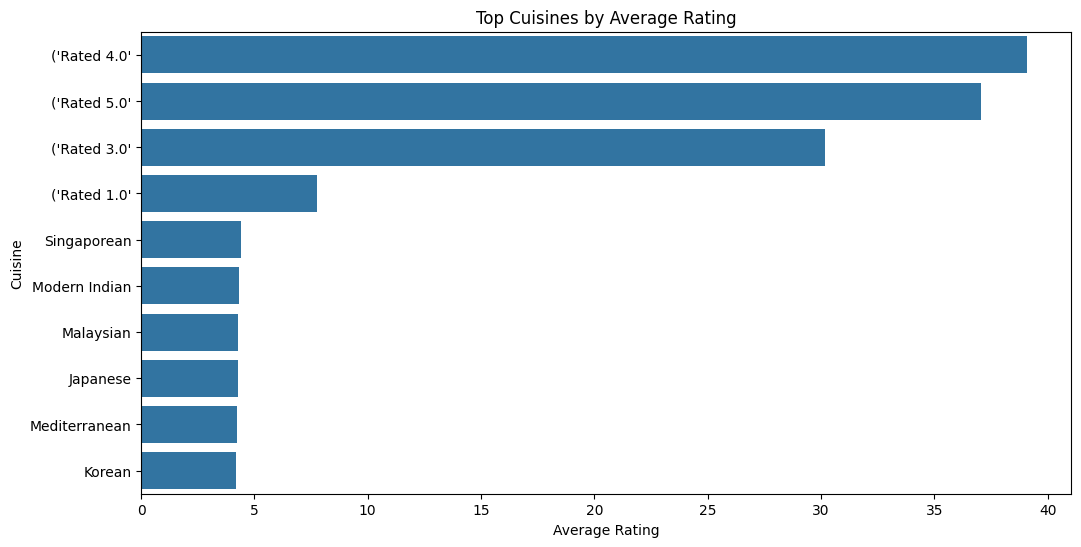

In [ ]:
#Top cuisines by rating
top_cuisines_rating = cuisine_analysis.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cuisines_rating,
    x="average_rating",
    y="cuisine"
)

plt.title("Top Cuisines by Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.show()

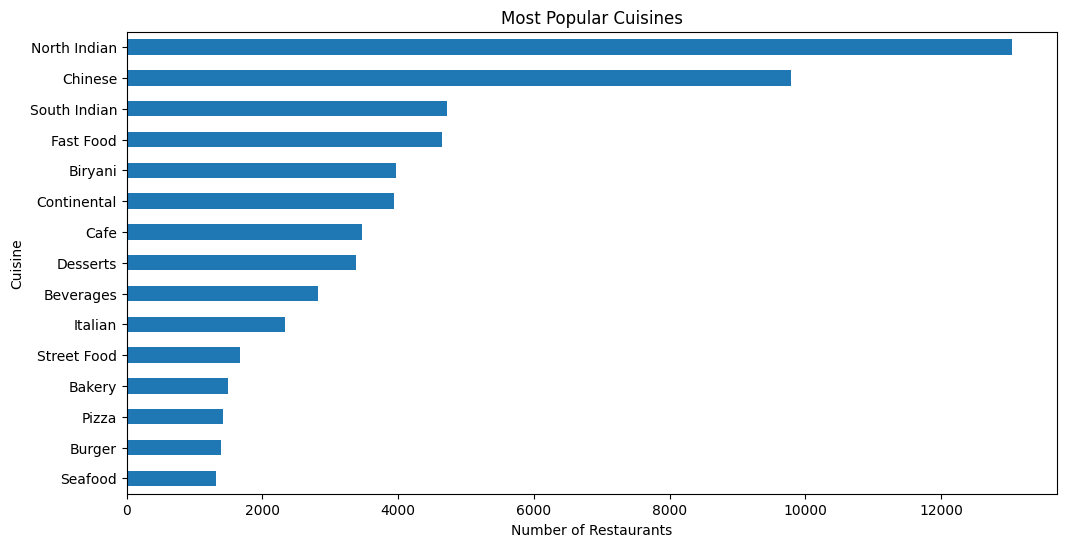

In [ ]:
#Most popular cuisines
popular_cuisines = (
    cuisine_df["cuisine"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12, 6))

popular_cuisines.sort_values().plot(kind="barh")

plt.title("Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.show()

In [ ]:
#Location hotspots
location_count = (
    df["location"]
    .value_counts()
    .head(15)
)

location_count

,count
location,
BTM,2900
Whitefield,1941
HSR,1843
Indiranagar,1765
Marathahalli,1668
Koramangala 5th Block,1659
JP Nagar,1487
Jayanagar,1327
Electronic City,1211


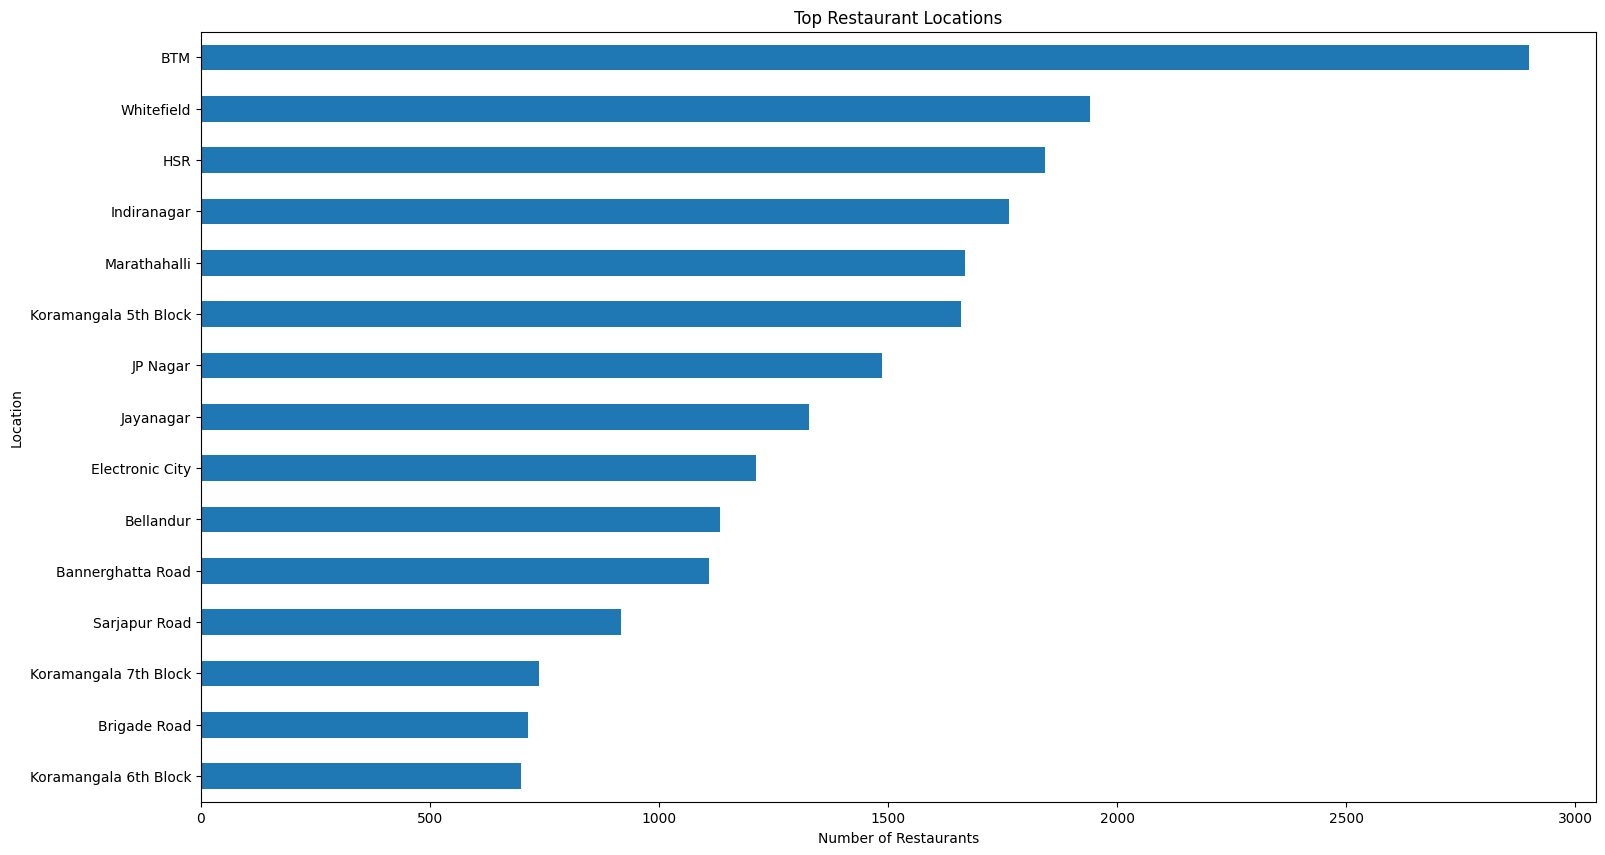

In [ ]:
#Visualization
plt.figure(figsize=(18, 10))

location_count.sort_values().plot(kind="barh")

plt.title("Top Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.show()

In [ ]:
#Location vs rating
location_rating = (
    rating_df
    .groupby("location")
    .agg(
        restaurant_count=("name", "count"),
        average_rating=("rate", "mean"),
        total_votes=("votes", "sum")
    )
    .reset_index()
)

location_rating = location_rating[
    location_rating["restaurant_count"] >= 30
]

location_rating = location_rating.sort_values(
    "average_rating",
    ascending=False
)

location_rating.head(15)

,location,restaurant_count,average_rating,total_votes
546,('Rated 3.0',49,93.969388,0.0
548,('Rated 4.0',136,51.367647,0.0
550,('Rated 5.0',114,21.766667,0.0
657,Lavelle Road,353,4.170538,378619.0
711,St. Marks Road,223,4.054260,210558.0
645,Koramangala 3rd Block,124,4.051613,75489.0
647,Koramangala 5th Block,1596,4.039787,1651278.0
583,Church Street,389,4.021337,460297.0
646,Koramangala 4th Block,581,3.946127,488922.0
586,Cunningham Road,277,3.944043,158302.0


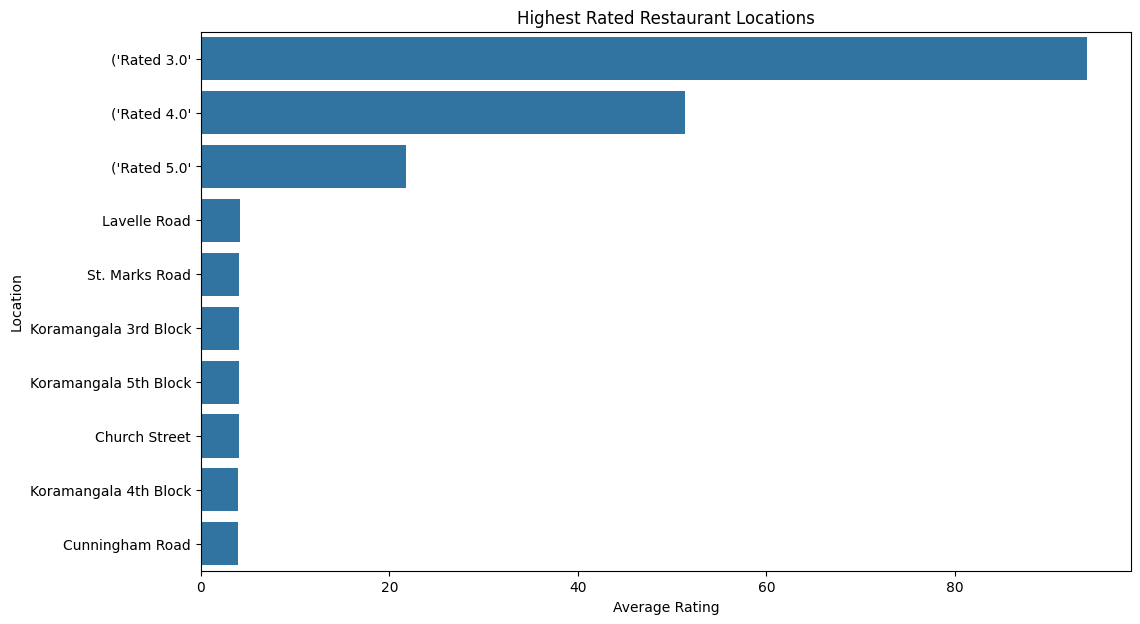

In [ ]:
#Visualization:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=location_rating.head(10),
    x="average_rating",
    y="location"
)

plt.title("Highest Rated Restaurant Locations")
plt.xlabel("Average Rating")
plt.ylabel("Location")

plt.show()

In [ ]:
#Price vs Rating
price_df = rating_df.dropna(
    subset=["approx_costfor_two_people"]
).copy()

price_df["price_range"] = pd.cut(
    price_df["approx_costfor_two_people"],
    bins=[0, 500, 1000, 1500, 2000, 3000, np.inf],
    labels=[
        "Below ₹500",
        "₹500–₹1000",
        "₹1000–₹1500",
        "₹1500–₹2000",
        "₹2000–₹3000",
        "Above ₹3000"
    ]
)

In [ ]:
#Average rating by price
price_rating = (
    price_df
    .groupby("price_range", observed=True)["rate"]
    .agg(["count", "mean"])
)

price_rating

,count,mean
price_range,,
Below ₹500,17802,3.590731
₹500–₹1000,8971,3.768933
₹1000–₹1500,2630,4.114221
₹1500–₹2000,841,4.184780
₹2000–₹3000,396,4.135859
Above ₹3000,63,4.263492


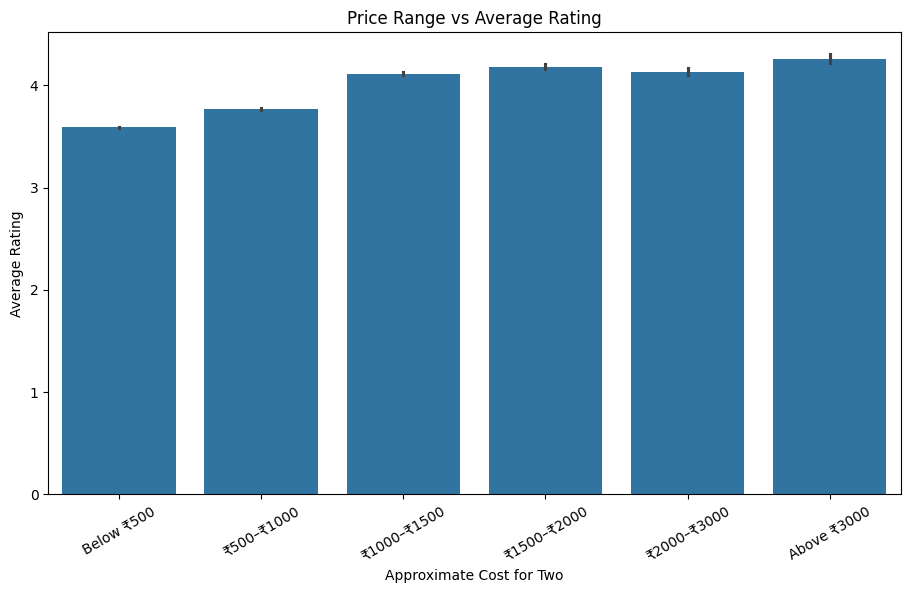

In [ ]:
#Visualization:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=price_df,
    x="price_range",
    y="rate",
    estimator="mean"
)

plt.title("Price Range vs Average Rating")
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Average Rating")

plt.xticks(rotation=30)

plt.show()

In [ ]:
#Correlation analysis
numeric_columns = [
    "rate",
    "votes",
    "approx_costfor_two_people"
]

corr = rating_df[numeric_columns].corr()

corr

,rate,votes,approx_costfor_two_people
rate,1.000000,0.429915,0.384962
votes,0.429915,1.000000,0.367006
approx_costfor_two_people,0.384962,0.367006,1.000000


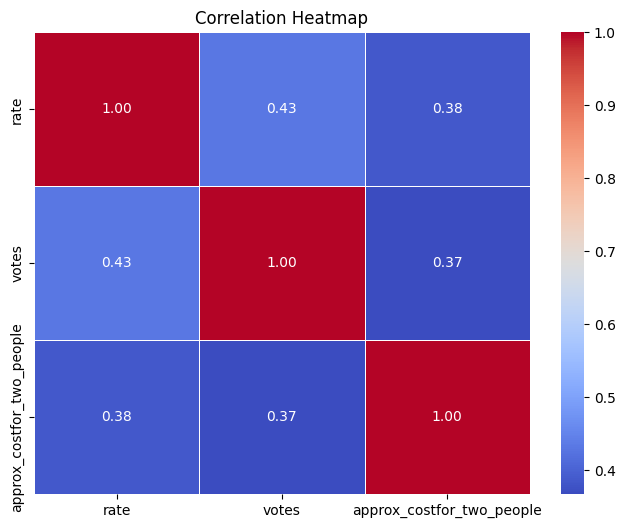

In [ ]:
#Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
#Restaurant type analysis
rest_type_count = (
    df["rest_type"]
    .value_counts()
    .head(15)
)

rest_type_count

,count
rest_type,
Quick Bites,13050
Casual Dining,7988
Cafe,2580
Delivery,1674
Dessert Parlor,1577
"Takeaway, Delivery",1303
"Casual Dining, Bar",869
Bakery,788
Beverage Shop,527


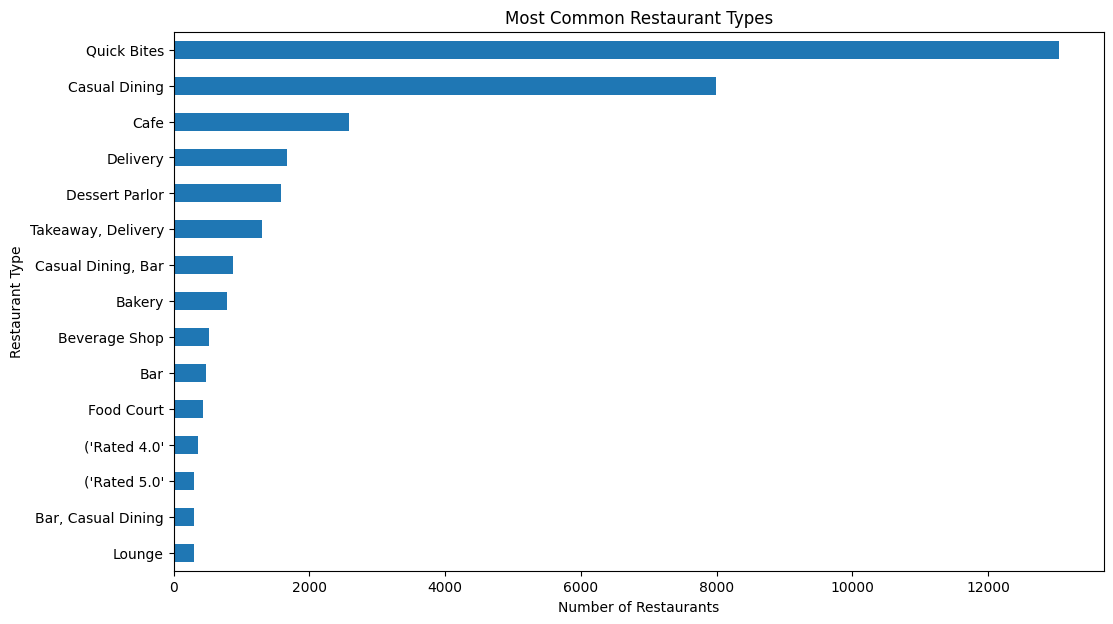

In [ ]:
plt.figure(figsize=(12, 7))

rest_type_count.sort_values().plot(kind="barh")

plt.title("Most Common Restaurant Types")
plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Type")

plt.show()

In [ ]:
#Restaurant type vs rating
rest_type_rating = (
    rating_df
    .groupby("rest_type")
    .agg(
        restaurant_count=("name", "count"),
        average_rating=("rate", "mean")
    )
    .reset_index()
)

rest_type_rating = rest_type_rating[
    rest_type_rating["restaurant_count"] >= 30
]

rest_type_rating.sort_values(
    "average_rating",
    ascending=False
).head(15)

,rest_type,restaurant_count,average_rating
374,('Rated 4.0',166,14.633133
372,('Rated 3.0',54,11.268519
376,('Rated 5.0',156,10.685897
368,('Rated 1.0',38,7.000000
370,('Rated 2.0',30,6.316667
541,"Pub, Microbrewery",59,4.450847
514,"Microbrewery, Casual Dining",88,4.370455
425,"Casual Dining, Microbrewery",42,4.290476
422,"Casual Dining, Cafe",227,4.229515
457,"Fine Dining, Bar",34,4.202941


In [ ]:
#Popular dishes
dish_df = df.dropna(subset=["dish_liked"]).copy()

dish_df["dish"] = dish_df["dish_liked"].str.split(",")

dish_df = dish_df.explode("dish")

dish_df["dish"] = dish_df["dish"].str.strip()

popular_dishes = dish_df["dish"].value_counts().head(20)

popular_dishes

,count
dish,
Pasta,2549
Burgers,2254
Cocktails,2174
Pizza,2093
Biryani,1660
Coffee,1518
Mocktails,1465
Sandwiches,1257
Paratha,1201


In [ ]:
!pip install wordcloud

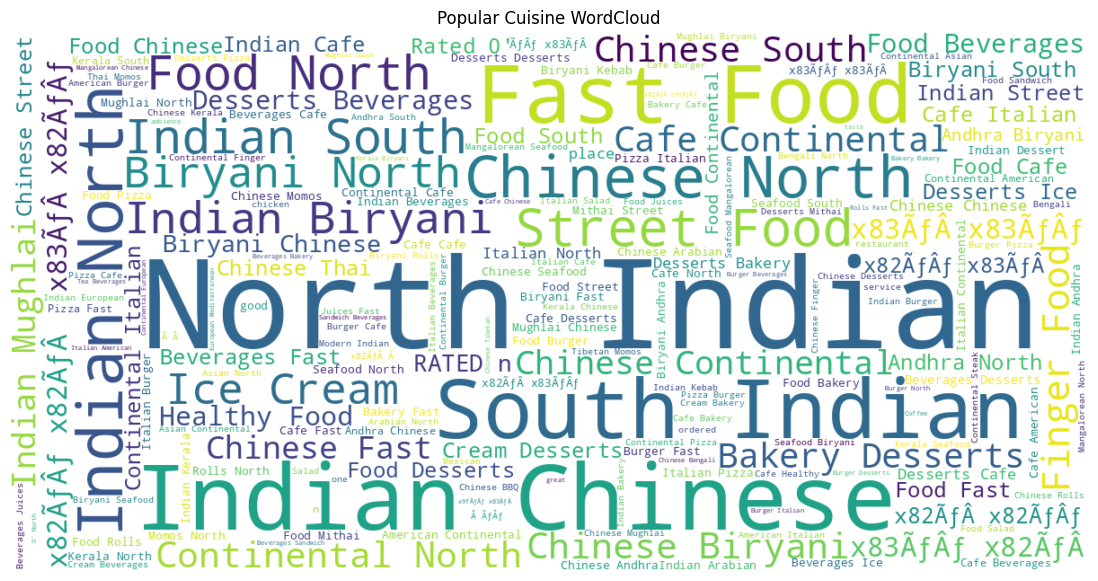

In [ ]:
from wordcloud import WordCloud

text = " ".join(
    cuisine_df["cuisine"]
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(text)

plt.figure(figsize=(15, 7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Popular Cuisine WordCloud")

plt.show()

In [ ]:
#Top 10 finding
print("========== ZOMATO ANALYSIS SUMMARY ==========")

print("\nTotal Restaurants:", df["name"].nunique())

print(
    "Average Rating:",
    round(rating_df["rate"].mean(), 2)
)

print(
    "\nTop Locations:"
)

print(
    df["location"]
    .value_counts()
    .head(10)
)

print(
    "\nMost Popular Cuisines:"
)

print(
    cuisine_df["cuisine"]
    .value_counts()
    .head(10)
)

print(
    "\nMost Popular Dishes:"
)

print(
    dish_df["dish"]
    .value_counts()
    .head(10)
)

========== ZOMATO ANALYSIS SUMMARY ==========

Total Restaurants: 11914
Average Rating: 5.37

Top Locations:
location
BTM                      2900
Whitefield               1941
HSR                      1843
Indiranagar              1765
Marathahalli             1668
Koramangala 5th Block    1659
JP Nagar                 1487
Jayanagar                1327
Electronic City          1211
Bellandur                1133
Name: count, dtype: int64

Most Popular Cuisines:
cuisine
North Indian    13054
Chinese          9796
South Indian     4721
Fast Food        4642
Biryani          3963
Continental      3932
Cafe             3465
Desserts         3383
Beverages        2814
Italian          2339
Name: count, dtype: int64

Most Popular Dishes:
dish
Pasta         2549
Burgers       2254
Cocktails     2174
Pizza         2093
Biryani       1660
Coffee        1518
Mocktails     1465
Sandwiches    1257
Paratha       1201
Noodles       1105
Name: count, dtype: int64


## 5 Business Recommendations

### 1. Location-Aware Restaurant Discovery
Use restaurant density, location and rating information to improve local restaurant discovery.

### 2. Cuisine-Based Recommendations
Create cuisine-focused collections and personalized restaurant recommendations based on cuisine popularity and rating patterns.

### 3. Price-Based Restaurant Segmentation
Provide budget, mid-range and premium restaurant categories based on approximate cost.

### 4. Improve Review Engagement
Use ratings together with vote volume to provide stronger customer-engagement signals.

### 5. Online Ordering Partnerships
Identify restaurant segments and locations where online ordering availability could create partnership opportunities.
